# Computational Linguistics: Practical Session 1 (7 October 2026): **solutions**

## Machine learning for NLP


Note: you are not required to submit any assignments for this practical session.

In this practical session, you will carry out a number of programming
exercises on machine learning for NLP, using Python. It will be helpful if you already know some basic Python (as provided in the first lectures of the course 'Scripting Languages', for example). But even you don't know anything about programming, you should be able to follow along with the examples.

For these exercises, we will make use of the interactive Python environment provided by Google Colab. The environment makes it possible to run Python code within your web browser. As an example, the code below computes the result of a sum, and outputs the result. Run the code by hovering over it, and pressing the play button in front.



In [ ]:
result = 2 + 2
print(result)

### Introduction

In this practical session, we explore machine learning models for
NLP applications; specifically, we build classifiers for
sentiment analysis on an English dataset of movie reviews (Maas et al., 2011).

The session is also the start of an experiment that continues through the five practical sessions. The same task, on the same data, is approached with each modelling paradigm discussed in the lectures: hand-written rules (the symbolic paradigm), a classifier trained on word counts (the statistical paradigm), word embeddings and a finetuned transformer (the neural paradigm), and finally a prompted large language model. Each session adds one or more rows to a single results table; in the last session, the models are compared and inspected. The set-up is the same as the one required for the course project.

### The data and the experimental set-up

We will use a set of movie reviews in English, extracted from the website
[imdb.com](https://www.imdb.com). The dataset consists of the text of the review, as
well as a sentiment label (positive or negative). Note that
the original ratings on IMDB range from 0 to 10 stars. We will use binary classification instead: original reviews of $\leq 4$ stars are considered negative, while
reviews of $\geq 7$ stars are considered positive. The dataset is
balanced, which means positive and negative instances are evenly distributed.

The 25,000 reviews are divided into three parts:

* a **training set** (18,000 reviews): the only data our models learn from;
* a **development set** (2,000 reviews), also called *validation set*: used for all decisions (features, classifier, rules, and later on prompts);
* a **test set** (5,000 reviews): used once, at the end, to report the performance of the final models.

Every time a score is inspected and the model is adapted accordingly, information about that data enters the model. If this is done on the test set, the final score no longer reflects the performance on unseen text, but the degree to which the model was tuned to those particular 5,000 reviews. Hence: **all decisions are made on the training and development data; the test set is used once.**

The cell below is identical in all five practical sessions: it downloads the data and rebuilds the same split with a fixed random seed, so that the results of different sessions are comparable (and so that you can continue if you missed a session). It also defines a helper function, `evaluate`, that computes accuracy and macro-averaged F1.

In [ ]:
# ==========================================================================
# SHARED DATA CELL -- identical in all five practical sessions. Do not change.
# It rebuilds exactly the same train / dev / test split every time it is run.
# ==========================================================================
import os
import tarfile
import urllib.request
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

if not os.path.exists('reviews_train.csv'):
    url = 'http://www.ccl.kuleuven.be/Courses/compling/data/review_dataset.tar.gz'
    urllib.request.urlretrieve(url, 'review_dataset.tar.gz')
    with tarfile.open('review_dataset.tar.gz') as tar:
        tar.extractall(filter='data')

SEED = 2627  # fixed seed: everybody gets the same split, in every session

train_full = pd.read_csv('reviews_train.csv', header=0, delimiter='\t', quoting=3)
test = pd.read_csv('reviews_test.csv', header=0, delimiter='\t', quoting=3)

# development set: 2000 reviews set aside from the training data
train, dev = train_test_split(train_full, test_size=2000, random_state=SEED,
                              stratify=train_full['sentiment'])
train = train.reset_index(drop=True)
dev = dev.reset_index(drop=True)

# small fixed samples, for the models that are slow at prediction time
dev_small = dev.sample(n=200, random_state=SEED).reset_index(drop=True)
test_small = test.sample(n=500, random_state=SEED).reset_index(drop=True)

print('train:', len(train), '| dev:', len(dev), '| test:', len(test),
      '| dev_small:', len(dev_small), '| test_small:', len(test_small))


def evaluate(name, gold, predicted):
    """Print (and return) accuracy and macro-averaged F1 for a list of predictions."""
    acc = accuracy_score(gold, predicted)
    f1 = f1_score(gold, predicted, labels=[0, 1], average='macro', zero_division=0)
    print('{:45s} accuracy = {:.3f} | macro-F1 = {:.3f}'.format(name, acc, f1))
    return acc, f1


A traditional machine learning pipeline for NLP applications generally consists of the following stages:

* data preprocessing (tokenization)
* feature extraction
* model training
* evaluation


We'll go through these stages step by step, using sentiment
classification as an application.

### Preprocessing

The shared cell has loaded the data with the `pandas` library, which facilitates data manipulation. We can now examine the training data, using the commands below. Note that negative sentiment is denoted by `0` and positive sentiment by `1`.

In [ ]:
train.head()

In [ ]:
print(train['review'][0])

Generally, we need to preprocess the dataset to be able to properly extract features from it. Within a computer, text is encoded as a continuous string of characters. For a computer, there is no difference between a space, a punctuation mark, or an alpha-numeric character. This means that a computer does not know about word or sentence boundaries. In order to analyze textual data within natural language processing applications, we first need to properly preprocess it. Note that our data has already been tokenized (i.e. words have been properly segmented), so we don't need to preprocess our data anymore.


### Baselines

Before training a model, we need a point of comparison. A score of 80% is good if a trivial method reaches 50%, and poor if a trivial method reaches 79%.

The simplest baseline is the **majority baseline**: always predict the most frequent label of the training set. `scikit-learn` (the module name of which is `sklearn`) provides it as the `DummyClassifier`. We evaluate it on the development set:

In [ ]:
from sklearn.dummy import DummyClassifier

majority = DummyClassifier(strategy='most_frequent')
majority.fit(train['review'], train['sentiment'])

evaluate('majority baseline (dev)', dev['sentiment'], majority.predict(dev['review']));

The dataset is balanced, so the majority baseline classifies about half of the reviews correctly. Note that accuracy and macro-averaged F1 differ here. The training set contains exactly 9,000 positive and 9,000 negative reviews; in case of a tie, `DummyClassifier` predicts the first label (`0`, negative), so all 2,000 development reviews are labelled negative:

| | predicted negative | predicted positive |
|---|---|---|
| **gold negative** | 1000 | 0 |
| **gold positive** | 1000 | 0 |

Precision, recall and F1 are computed per class:

* class *negative*: precision = 1000 / 2000 = 0.5, recall = 1000 / 1000 = 1, F1 = 2 · 0.5 · 1 / (0.5 + 1) = 0.667
* class *positive*: nothing is predicted as positive, so precision is undefined (0 / 0, set to 0 by convention), recall = 0 / 1000 = 0, and F1 = 0

Macro-averaged F1 is the mean over the two classes: (0.667 + 0) / 2 = 0.333, while accuracy is 1000 / 2000 = 0.5. The macro-F1 is low because the baseline ignores one of the two classes entirely. On a balanced dataset the two measures are usually close for any reasonable model; on an imbalanced dataset (spam, toxic comments), accuracy can be high for a model that is useless, while macro-F1 reveals this.

#### A symbolic classifier: a sentiment lexicon

The second baseline is a classifier in the **symbolic paradigm**: nothing is learned from data. Instead, linguistic knowledge is written down in the form of a small sentiment lexicon and a rule: count the positive and the negative words in a review, and predict the label with the highest count.

In [ ]:
positive_words = {'good', 'great', 'excellent', 'wonderful', 'best', 'love', 'loved',
                  'amazing', 'brilliant', 'perfect', 'favorite', 'enjoyed', 'enjoyable',
                  'beautiful', 'fantastic', 'superb', 'fun', 'touching', 'masterpiece',
                  'recommend'}

negative_words = {'bad', 'worst', 'awful', 'terrible', 'boring', 'waste', 'poor',
                  'horrible', 'stupid', 'dull', 'worse', 'ridiculous', 'disappointing',
                  'disappointed', 'annoying', 'lame', 'mess', 'pointless', 'poorly',
                  'avoid'}


def lexicon_classifier(review):
    # our reviews have already been tokenized, so we can simply split on spaces
    words = review.split()
    n_positive = sum(1 for w in words if w in positive_words)
    n_negative = sum(1 for w in words if w in negative_words)
    # rule: the label with the highest count wins (a tie counts as positive)
    if n_positive >= n_negative:
        return 1
    else:
        return 0


lexicon_predictions = [lexicon_classifier(review) for review in dev['review']]
evaluate('sentiment lexicon (dev)', dev['sentiment'], lexicon_predictions);

With forty words and one rule, the classifier scores well above the majority baseline. The same computation as above, now for a model that does predict both classes:

| | predicted negative | predicted positive |
|---|---|---|
| **gold negative** | 449 | 551 |
| **gold positive** | 41 | 959 |

* class *negative*: precision = 449 / 490 = 0.916, recall = 449 / 1000 = 0.449, F1 = 0.603
* class *positive*: precision = 959 / 1510 = 0.635, recall = 959 / 1000 = 0.959, F1 = 0.764

Accuracy = (449 + 959) / 2000 = 0.704; macro-F1 = (0.603 + 0.764) / 2 = 0.683. The two classes behave very differently: the lexicon finds almost all positive reviews, but misses more than half of the negative ones. The per-class scores show this; a single accuracy figure does not. (Reviews with an equal number of positive and negative words, including reviews without any lexicon word, are labelled positive by the rule; this is one reason for the imbalance.)

Note also that this classifier is **fully interpretable**: for any review, we can determine exactly why it took its decision. We come back to this at the end of the session, and in session 5.

#### Exercise 1

1. Examine a number of development reviews that the lexicon classifier gets wrong. Why does it fail?
2. Try to improve the classifier: add words to the lexicon, and/or add a rule (for example a simple treatment of negation: *not good*, *never boring*). Evaluate your changes on the **development set**, not on the test set. How much do you gain, and how much work does it take?
3. Store your best rule-based classifier in a function called `my_lexicon_classifier`; it is needed at the end of the session.

In [ ]:
### YOUR CODE HERE

# 1. Looking at the errors: many misclassified reviews contain sentiment words
#    that are not about the movie as a whole ('the best thing about this movie
#    is that it ends'), that are negated ('not good'), or they mix praise and
#    criticism; and quite a few reviews contain no lexicon words at all, so that
#    the (arbitrary) tie rule decides.

errors = [i for i in range(len(dev)) if lexicon_predictions[i] != dev['sentiment'][i]]
print(len(errors), 'errors on', len(dev), 'development reviews')
print(dev['sentiment'][errors[0]], dev['review'][errors[0]][:600])

# 2. An extended lexicon, and a simple negation rule: a sentiment word that is
#    preceded by a negation word (within a window of two words) counts for the
#    opposite polarity.

more_positive = {'hilarious', 'delightful', 'terrific', 'outstanding',
                 'solid', 'gem', 'moving', 'captivating', 'refreshing', 'memorable',
                 'stunning', 'powerful', 'awesome', 'charming', 'incredible', 'liked'}
more_negative = {'unfunny', 'laughable', 'pathetic', 'garbage', 'crap', 'dreadful',
                 'horrid', 'tedious', 'wasted', 'unwatchable', 'insult', 'fails',
                 'badly', 'mediocre', 'forgettable', 'cheap', 'sucks', 'redeeming'}

my_positive = positive_words | more_positive
my_negative = negative_words | more_negative
negations = {'not', "n't", 'never', 'no', 'hardly', 'nothing'}


def my_lexicon_classifier(review):
    words = review.split()
    score = 0
    for i, w in enumerate(words):
        polarity = 1 if w in my_positive else -1 if w in my_negative else 0
        if polarity and any(prev in negations for prev in words[max(0, i - 2):i]):
            polarity = -polarity
        score += polarity
    return 1 if score >= 0 else 0


my_lexicon_predictions = [my_lexicon_classifier(review) for review in dev['review']]
evaluate('extended lexicon + negation (dev)', dev['sentiment'], my_lexicon_predictions);

# The gain is real but modest (a few points), and every further point costs more
# work than the previous one: there are always more words and more constructions.
# This is the typical profile of the symbolic paradigm: transparent and precise
# where it has knowledge, but with limited coverage, and expensive to extend.

### Feature extraction

We now move to the **statistical paradigm**: instead of writing down the knowledge ourselves, a model learns from the labelled training data which words are relevant. First, we need to decide which features to use in our classifier. We’ll start with simple bag of words features. For this, we can make use of `scikit-learn`'s `CountVectorizer` object. `scikit-learn` is a well known Python library that implements a wide range of machine learning algorithms. `CountVectorizer` is part of `scikit-learn`'s feature extraction toolkit; it allows us to convert a collection of documents to a matrix of token counts (one feature vector for each review). We define the parameter `max_features` to be 500, which means only the 500 most frequent words will be taken into account. Once we have defined the `CountVectorizer` object, we can perform the actual feature extraction using the function `fit_transform`.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(analyzer = 'word', max_features = 500)
train_data_features = vectorizer.fit_transform(train['review'])

Using the command below, we can inspect the shape of the resulting matrix:

In [ ]:
print(train_data_features.shape)

The output above tells us that we have a matrix of 18000 documents (reviews), by 500 word features. Each matrix cell represents the frequency of each of the 500 words within a particular review.

We can also inspect which are the 500 most frequent words that are used as features, using the command below:

In [ ]:
vocab = vectorizer.get_feature_names_out()
print(vocab)

### Classification

`scikit-learn` contains many different implementations of classification algorithms. We’ll start with the classifier we examined during the lectures: a naive Bayes classifier. The naive Bayes classifier is represented by the `MultinomialNB` class. Once we have instantiated it, we can train it on our data using the `fit` function. Note that we are providing to the function both the features extracted for each review (`train_data_features`) and the correct sentiment label (`train['sentiment']`) for each review. In the training step, we need to provide our model with the correct answer.

In [ ]:
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB()

classifier.fit(train_data_features, train['sentiment'])

Our model has now been trained on the training set; we can now measure its performance on the **development set**. First, we carry out the same feature extraction on the development set. Note that we use the function `transform` here, and not `fit_transform`: the vocabulary has been determined on the training set, and should not be influenced by any other data.

In [ ]:
dev_data_features = vectorizer.transform(dev['review'])

Next, we can compute the performance on the development set.

In [ ]:
score = classifier.score(dev_data_features, dev['sentiment'])
print(score)

#### Exercise 2



1.   What does the score represent? How does it compare to our two baselines?
2.   Look at the instances that were classified badly. Do you see why certain reviews are misclassified? Hint: use the function `predict`.



In [ ]:
### YOUR CODE HERE

# the score represents the accuracy of the classifier: how many instances are
# predicted correctly (i.e., have the same label as the gold label in the
# development set?) With only 500 word-count features, naive Bayes already
# clearly outperforms our hand-written lexicon.

results = classifier.predict(dev_data_features)

# the function `predict` provides predictions for each individual instance,
# which we can compare to the gold labels

errors = [i for i in range(len(dev)) if results[i] != dev['sentiment'][i]]
print(len(errors), 'errors; the first ones are reviews', errors[:10])

# instances with incorrect predictions often contain ambivalent reviews, which
# talk about positive aspects within an overall negative review (or the other
# way round), or which mainly summarize the plot, e.g.

print('Review #{}:'.format(errors[0]), dev['review'][errors[0]])

### K-fold cross validation

Usually, we will want to try out different parameters, in order to see what works best for our task. As such, we might experiment with:


* Different features
* Different classification algorithms
* Different model parameters


As explained above, the test set cannot be used for this. We could use the development set, but there is an alternative that uses the data more efficiently and gives a more reliable estimate than a single development set: **k-fold cross validation** on the training set. The idea is the following:

* Break up data into $k$ (e.g. 10) parts (folds)
* For each fold

    * Current fold is used as **validation** set
    * Use other 9 folds as training data
    * Performance is computed on the validation fold

*  Average performance over 10 runs

A graphical representation of 10-fold cross validation is given below:


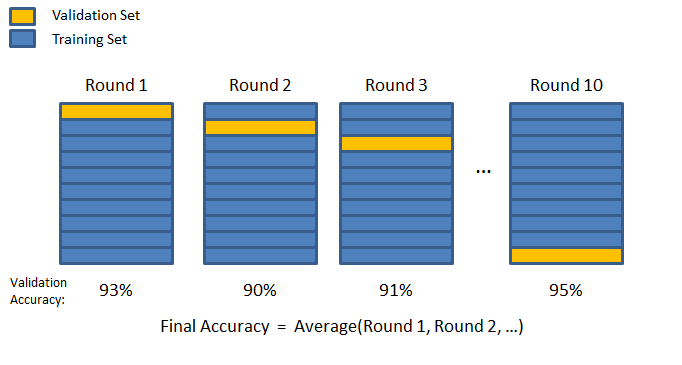

K-fold cross validation is implemented in the `StratifiedKFold` class. 'Stratified' means that we keep the number of positive and negative instances in the training and validation folds balanced throughout the cross-validation steps.

In [ ]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=10)
score_kfold = []

for n_fold, (train_indices, val_indices) in enumerate(kf.split(train_data_features, train['sentiment'])):
    X_train, X_val = train_data_features[train_indices], train_data_features[val_indices]
    y_train, y_val = train['sentiment'][train_indices], train['sentiment'][val_indices]

    classifier.fit(X_train, y_train)
    print('Score on fold' , n_fold, ':', classifier.score(X_val, y_val))
    score_kfold.append(classifier.score(X_val, y_val))

print('Average performance: ', sum(score_kfold) / len(score_kfold))

Note that the scores on the different folds differ by about one point, although model and features are identical. This matters when comparing two models: a difference smaller than the variation between folds is not a reliable result.

#### Exercise 3

* Experiment with different feature sets
    * Experiment with n-grams instead of bag of words (hint: look at the arguments of CountVectorizer again in order to extract n-grams)

    * Change the number of vocabulary elements included in the model

* Experiment with different models

    * Try [a naive bayes classifier that uses binary features](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html) (word presence instead of word count)
    * Try [any other classifier included with scikit-learn](https://scikit-learn.org/stable/supervised_learning.html) (e.g. [decision trees](https://scikit-learn.org/stable/modules/tree.html), or [logistic regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression)) How does it perform?

* When you’ve determined the best set of parameters (according to cross-validation), train that model on the complete training set, and store it in the variables `vectorizer` and `classifier`. Do **not** compute the performance on the test set yet: we will do that once, for all our models, at the end of this session.

In [ ]:
### YOUR CODE HERE

### You can either copy the code you want to adapt here, or you can just change
### the values in the existing code snippets above

from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression

# we use 20000 features, which can consist of unigrams (single words) or bigrams
vectorizer = CountVectorizer(analyzer = 'word',
                             max_features = 20000,
                             ngram_range=(1,2))


train_data_features = vectorizer.fit_transform(train['review'])

vocab = vectorizer.get_feature_names_out()

# we'll test three classifiers using 5-fold cross validation

clf_NB = MultinomialNB()
clf_binNB = BernoulliNB()
clf_lr = LogisticRegression(max_iter=1000)

all_clf = [clf_NB, clf_binNB, clf_lr]

kf = StratifiedKFold(n_splits=5)
score_kfold = [ [] for i in range(len(all_clf))]

for n_fold, (train_indices, test_indices) in enumerate(kf.split(train_data_features, train['sentiment'])):
    X_train, X_test = train_data_features[train_indices], train_data_features[test_indices]
    y_train, y_test = train['sentiment'][train_indices], train['sentiment'][test_indices]

    for i, clf in enumerate(all_clf):
      clf.fit(X_train, y_train)
      print(clf, ': Score on fold' , n_fold, ':', clf.score(X_test, y_test))
      score_kfold[i].append(clf.score(X_test, y_test))

for i, clf in enumerate(all_clf):
  print(clf, ': Average performance: ', sum(score_kfold[i]) / len(score_kfold[i]))

# logistic regression works best according to cross-validation, so we'll choose
# this classifier, and train it on all our training data; we keep the test set
# for the end of the session

classifier = LogisticRegression(max_iter=1000)
classifier.fit(train_data_features, train['sentiment'])

### Intrinsic model evaluation

A score indicates how well a model works, but not what it has learned. Some models allow us to inspect the most informative features. A logistic regression learns one weight (coefficient) for each feature: a positive weight pushes the decision towards the positive class, a negative weight towards the negative class. Using a logistic
regression, you can do the following:

In [ ]:
from sklearn.linear_model import LogisticRegression

# (we re-create the features here, so that this cell also works if you
# changed the variables above in a different way)
vectorizer = CountVectorizer(analyzer = 'word', max_features = 20000, ngram_range=(1,2))
train_data_features = vectorizer.fit_transform(train['review'])
vocab = vectorizer.get_feature_names_out()

classifier = LogisticRegression(max_iter=1000)
classifier.fit(train_data_features, train['sentiment'])

allCoefficients = [(classifier.coef_[0,i], vocab[i]) for i in range(len(vocab))]

allCoefficients.sort()
allCoefficients.reverse()

#### Exercise 4

1. Examine the top and the bottom features of the `allCoefficients` list. Which features are the most informative?
2. Compare them to the sentiment lexicon written by hand at the beginning of this session. Which lexicon words did the model find as well? Which of the model's top features are unexpected, and are they all sentiment words?
3. Look up the weights of a few words you are curious about (e.g. *not*, *plot*, *script*, or the name of an actor or director).

In [ ]:
### YOUR CODE HERE

print(allCoefficients[0:25])
print(allCoefficients[-25:])

# 1./2. The top positive features contain words we had in our lexicon as well
# (superb, perfect, excellent, wonderful, enjoyable, ...), but also words and
# word pairs a lexicon writer does not readily think of: 'refreshing',
# 'believable', 'definitely worth', 'well worth', 'very well', and even a
# rating ('10 10'). The negative side is similar: 'worst', 'waste', 'awful',
# 'boring', 'poorly', but also 'disappointment', 'lacks', 'fails', 'let down',
# 'just not' -- and negated bigrams such as 'not good', 'not worth' and
# 'not recommend': with bigram features, the statistical model has discovered
# (a little bit of) negation by itself.
# Not everything is a sentiment word: some features are properties of this
# particular dataset (ratings that reviewers mention in the text, genres,
# names). The model has learned what predicts the label in THIS data, which is
# not necessarily what expresses sentiment in English ('today', 'when was',
# 'than this', 'save').

coefficient_of = {word: weight for weight, word in allCoefficients}
for word in ['good', 'great', 'bad', 'not', 'not good', 'plot', 'script', 'seagal']:
    print(word, coefficient_of.get(word, 'not in the vocabulary'))

in_lexicon = [w for w in positive_words | negative_words if w in coefficient_of]
agree = [w for w in in_lexicon
         if (coefficient_of[w] > 0) == (w in positive_words)]
print(len(agree), 'of our', len(in_lexicon), 'lexicon words have a weight with the expected sign')

This is a first encounter with **interpretability**, a theme that returns throughout the course. The symbolic classifier is transparent by construction: we wrote the rules. The statistical classifier is still reasonably transparent: it consists of 20,000 weights that can be inspected. For the neural models of the next sessions, this is considerably harder; we come back to it in practical session 5.

### Final evaluation on the test set

All decisions have been made; we now evaluate the models on the test set. We report accuracy and macro-averaged F1 for:

1. the majority baseline;
2. the sentiment lexicon (if you made an improved version in exercise 1, use that one; it was developed on the development set, which is allowed);
3. the best statistical classifier, as determined by cross-validation.

Note the difference between **selecting** and **reporting**. Which features, which classifier and which lexicon rules to use was decided on the training and development data. The test scores below are only reported: they indicate how well the chosen models perform on unseen data. They are not used to choose between models or to adjust them afterwards; a model that is changed because of its test score would turn the test set into a second development set, and the reported score would no longer be meaningful.

In [ ]:
# 1. majority baseline
evaluate('1. majority baseline (test)', test['sentiment'], majority.predict(test['review']))

# 2. sentiment lexicon (change to my_lexicon_classifier if you made one in exercise 1)
evaluate('2. sentiment lexicon (test)', test['sentiment'],
         [lexicon_classifier(review) for review in test['review']])

# 3. statistical classifier: bag of words (and bigrams) + logistic regression
test_data_features = vectorizer.transform(test['review'])
evaluate('3. bag of words + classifier (test)', test['sentiment'],
         classifier.predict(test_data_features));

**Solution note.** With the extended lexicon and the negation rule of exercise 1, the symbolic classifier gains a few points on the test set as well:

In [ ]:
evaluate('2b. extended lexicon + negation (test)', test['sentiment'],
         [my_lexicon_classifier(review) for review in test['review']]);

### The results table

Reference numbers for the first three rows (row 2 is the basic 40-word lexicon; your own numbers may differ slightly, depending on the choices made in the exercises). The table is completed in the following sessions.

| # | model | paradigm | accuracy | macro-F1 | session |
|---|---|---|---|---|---|
| 1 | majority baseline | – | 0.500 | 0.333 | 1 |
| 2 | sentiment lexicon (rules) | symbolic | 0.717 | 0.700 | 1 |
| 3 | bag of words + naive Bayes / logistic regression | statistical | 0.875 | 0.875 | 1 |
| 4 | averaged word embeddings + logistic regression | neural (static embeddings) | *(later)* | *(later)* | 2 |
| 5 | finetuned DistilBERT | neural (pretrained transformer) | *(later)* | *(later)* | 3 |
| 6 | prompted LLM (zero-/few-shot), on `test_small` | in-context | *(later)* | *(later)* | 4 |

The models of this session are now final. Changing the lexicon or the features on the basis of the test scores would violate the rule stated at the start.

### References

Andrew L. Maas, Raymond E. Daly, Peter T. Pham, Dan Huang, Andrew Y. Ng, and Christopher Potts. 2011. Learning Word Vectors for Sentiment Analysis. The 49th Annual Meeting of the Association for Computational Linguistics (ACL 2011).